In [1]:
keywords = {
    "Anggaran": [
        "dana",
        "anggaran",
        "apbn",
        "biaya",
    ],

    "Politik":[
        "prabowo",
        "kampanye",
        "politik",

    ],

    "Kualitan Pangan":[
        'bergizi',
        'belatung',
        'keracunan',
        'makanan',
    ],
    "Distribusi":[
        'distribusi'
        'penyaluran'
        'pengiriman'
        'daerah'
        'sampai'
    ],

    "Ekonomi":[
        'ekonomi',
        'umkm',
        'lapangan',
        'lokal',
        'kerja',
        'masyarakat',
        'banyak',
    ],

    "Tata Kelola":[
        'aturan'
        'regulasi'
        'pengawasan'
        'evaluasi'
        'pelaksanaan'
        'mekanisme'
        'koordinasi'
        'kementerian'
        'bgn'
        'prosedur'
    ],

    "Sasaran Penerima":[
        'siswa'
        'anak sekolah'
        'pelajar'
        'penerima'
        'target'
        'anak sd'
        'murid'
    ],

    "lainnya":[
        'makanan'
    ]
}

In [40]:
#import libary yang dibutuhkan
from collections import Counter
import re
import pandas as pd
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory, ArrayDictionary, StopWordRemover
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from nltk.tokenize import word_tokenize
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')



[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\NICHO\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\NICHO\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [42]:
# buat nyari kata yang sering muncul sesuai label yg diminta
text = " ".join(
    train[train['label'] == 'lainnya']['full_text']
)
words = text.lower().split()
counter = Counter(words)
print(counter.most_common(90))


[]


In [57]:
#buat baca datanya
train = pd.read_excel("excel/case_1_labeled_data.xlsx")
test = pd.read_excel("excel/case_1_text_to_predict.xlsx")
train['clean_text'] = train['full_text'].apply(clean_text)
# test['clean_text'] = test['text'].apply(clean_text)
train.head()



,full_text,label,clean_text
0,@ARSIPAJA Pret. Di sekolah gw dapet MBG tetep ...,Sasaran Penerima,pret. di sekolah gw dapet mbg tetep aja anak-a...
1,MBG bentuk penggarongan duit negara secara TSM...,Politik,mbg bentuk penggarongan duit negara secara tsm...
2,@inzhapt_76 @ARSIPAJA Pasal 34 ayat (1) Undang...,Sasaran Penerima,pasal 34 ayat (1) undang-undang dasar negara r...
3,Makan Bergizi Gratis bikin masyarakat ngerasa ...,Sasaran Penerima,makan bergizi gratis bikin masyarakat ngerasa ...
4,"@OniSuryaman Presiden ngotot, paling sebel kal...",Politik,"presiden ngotot, paling sebel kalau mbg dikrit..."


In [59]:
# Cek NaN values
print("=== Status Data Awal ===")
print("Jumlah data:", len(train))
print("\nNilai NaN per kolom:")
print(train.isnull().sum())

# Tangani NaN Label
train['clean_text'] = train['clean_text'].fillna('')  # Isi NaN dengan string kosong
train = train.dropna(subset=['label'])  # Hapus baris yang tidak memiliki label

print("\n=== Status Data Setelah Pembersihan ===")
print("Jumlah data:", len(train))
print("\nDistribusi label:")
print(train['label'].value_counts())

=== Status Data Awal ===
Jumlah data: 5000

Nilai NaN per kolom:
full_text     0
label         0
clean_text    0
dtype: int64

=== Status Data Setelah Pembersihan ===
Jumlah data: 5000

Distribusi label:
label
Kualitas Pangan     1247
Politik              792
Anggaran             727
Lainnya              638
Tata Kelola          511
Sasaran Penerima     507
Distribusi           433
Ekonomi              145
Name: count, dtype: int64


In [43]:
# 1. PROSES CASE FOLDING

def clean_text(text):
    if isinstance(text, str):
        text = re.sub(r'@\w+', ' ', text)                          # remove username
        text = re.sub(r'(wk){2,}k?', '', text, flags=re.IGNORECASE)  # wkwk, wkwkk dst
        text = re.sub(r'(ha){2,}', '', text, flags=re.IGNORECASE)  # haha, hahaha dst
        text = re.sub(r'(hi){2,}', '', text, flags=re.IGNORECASE)  # hihi, hihihi dst
        text = re.sub(r'(he){2,}', '', text, flags=re.IGNORECASE)  # hehe, hehehe dst
        text = re.sub(r'\s+', ' ', text).strip()                   # rapikan spasi
        text = text.lower()                                         # case folding
    return text

test['clean_text'] = test['full_text'].apply(clean_text)
test['label'] = train['label']

print("Setelah Case Folding + Remove Username:")
display(test[['full_text', 'label', 'clean_text']].head())

Setelah Case Folding + Remove Username:


,full_text,label,clean_text
0,@yeahhhmaybe mbg di sekolah kota saya belum ad...,Sasaran Penerima,mbg di sekolah kota saya belum ada yg dpt mala...
1,@thefineshytguy WKWKKdidaerah ku pun yg dapat ...,Politik,didaerah ku pun yg dapat mbg baru beberapa sek...
2,"@ARSIPAJA Tai tau enggak ,gak semua sekolah da...",Sasaran Penerima,"tai tau enggak ,gak semua sekolah dapat mbg da..."
3,"Gencar Cegah Stunting, MBG Telah Capai 49% Sas...",Sasaran Penerima,"gencar cegah stunting, mbg telah capai 49% sas..."
4,140 siswa kupang Keracunan program MBG @prabowo,Politik,140 siswa kupang keracunan program mbg


In [44]:
def remove_special_characters(text: str) -> str:
    #remove karakter spesial
    processed_text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    return processed_text

test['clean_text'] = test['clean_text'].apply(remove_special_characters)

print("Setelah Remove Special Characters:")
test['label'] = train['label']
display(test[['full_text', 'label', 'clean_text']].head())

Setelah Remove Special Characters:


,full_text,label,clean_text
0,@yeahhhmaybe mbg di sekolah kota saya belum ad...,Sasaran Penerima,mbg di sekolah kota saya belum ada yg dpt malahan
1,@thefineshytguy WKWKKdidaerah ku pun yg dapat ...,Politik,didaerah ku pun yg dapat mbg baru beberapa sek...
2,"@ARSIPAJA Tai tau enggak ,gak semua sekolah da...",Sasaran Penerima,tai tau enggak gak semua sekolah dapat mbg dan...
3,"Gencar Cegah Stunting, MBG Telah Capai 49% Sas...",Sasaran Penerima,gencar cegah stunting mbg telah capai 49 sasar...
4,140 siswa kupang Keracunan program MBG @prabowo,Politik,140 siswa kupang keracunan program mbg


In [45]:
def removedigitangka(text: str) -> str:
    # menghilangkan digit angka
    text = re.sub(r'\d+', '', text)
    return text

test['clean_text'] = test['clean_text'].apply(removedigitangka)

print("Setelah Remove digit:")
test['label'] = train['label']
display(test[['full_text', 'label', 'clean_text']].head())

Setelah Remove digit:


,full_text,label,clean_text
0,@yeahhhmaybe mbg di sekolah kota saya belum ad...,Sasaran Penerima,mbg di sekolah kota saya belum ada yg dpt malahan
1,@thefineshytguy WKWKKdidaerah ku pun yg dapat ...,Politik,didaerah ku pun yg dapat mbg baru beberapa sek...
2,"@ARSIPAJA Tai tau enggak ,gak semua sekolah da...",Sasaran Penerima,tai tau enggak gak semua sekolah dapat mbg dan...
3,"Gencar Cegah Stunting, MBG Telah Capai 49% Sas...",Sasaran Penerima,gencar cegah stunting mbg telah capai sasaran...
4,140 siswa kupang Keracunan program MBG @prabowo,Politik,siswa kupang keracunan program mbg


In [46]:
def removeurl(text: str) -> str:
    # menghilangkan url
    text = re.sub(r'https?:\/\/\S+','',text)
    return text

test['clean_text'] = test['clean_text'].apply(removeurl)

print("Setelah Remove url:")
test['label'] = train['label']
display(test[['full_text', 'label', 'clean_text']].head())

Setelah Remove url:


,full_text,label,clean_text
0,@yeahhhmaybe mbg di sekolah kota saya belum ad...,Sasaran Penerima,mbg di sekolah kota saya belum ada yg dpt malahan
1,@thefineshytguy WKWKKdidaerah ku pun yg dapat ...,Politik,didaerah ku pun yg dapat mbg baru beberapa sek...
2,"@ARSIPAJA Tai tau enggak ,gak semua sekolah da...",Sasaran Penerima,tai tau enggak gak semua sekolah dapat mbg dan...
3,"Gencar Cegah Stunting, MBG Telah Capai 49% Sas...",Sasaran Penerima,gencar cegah stunting mbg telah capai sasaran...
4,140 siswa kupang Keracunan program MBG @prabowo,Politik,siswa kupang keracunan program mbg


In [47]:
# Fungsi untuk menghapus HTML
def remove_html(text: str) ->str:
    if text is not None and isinstance(test, str):
        html = re.compile(r'<.*?>')
        return html.sub(r'', text)
    else:
        return text
    
test['clean_text'] = test['clean_text'].apply(remove_html)

print("Setelah Remove html:")
test['label'] = train['label']
display(test[['full_text', 'label', 'clean_text']].head())

Setelah Remove html:


,full_text,label,clean_text
0,@yeahhhmaybe mbg di sekolah kota saya belum ad...,Sasaran Penerima,mbg di sekolah kota saya belum ada yg dpt malahan
1,@thefineshytguy WKWKKdidaerah ku pun yg dapat ...,Politik,didaerah ku pun yg dapat mbg baru beberapa sek...
2,"@ARSIPAJA Tai tau enggak ,gak semua sekolah da...",Sasaran Penerima,tai tau enggak gak semua sekolah dapat mbg dan...
3,"Gencar Cegah Stunting, MBG Telah Capai 49% Sas...",Sasaran Penerima,gencar cegah stunting mbg telah capai sasaran...
4,140 siswa kupang Keracunan program MBG @prabowo,Politik,siswa kupang keracunan program mbg


In [48]:
def remove_emoji(text: str) -> str:
    if text is not None and isinstance(text, str):
        emoji_pattern = re.compile("["
            u"\U0001F600-\U0001F64F"  # emoticons
            u"\U0001F300-\U0001F5FF"  # symbols & pictographs
            u"\U0001F680-\U0001F6FF"  # transport & map symbols
            u"\U0001F700-\U0001F77F"  # alchemical symbols
            u"\U0001F780-\U0001F7FF"  # Geometric Shapes Extended
            u"\U0001F800-\U0001F8FF"  # Supplemental Arrows-C
            u"\U0001F900-\U0001F9FF"  # Supplemental Symbols and Pictographs
            u"\U0001FA00-\U0001FA6F"  # Chess Symbols
            u"\U0001FA70-\U0001FAFF"  # Symbols and Pictographs Extended-A
            u"\U0001F004-\U0001F0CF"  # Additional emoticons
            u"\U0001F1E0-\U0001F1FF"  # flags
                               "]+", flags=re.UNICODE)
        return emoji_pattern.sub(r'', text)
    else:
        return text
    
test['clean_text'] = test['clean_text'].apply(remove_emoji)

print("Setelah Remove emoji:")
test['label'] = train['label']
display(test[['full_text', 'label', 'clean_text']].head())

Setelah Remove emoji:


,full_text,label,clean_text
0,@yeahhhmaybe mbg di sekolah kota saya belum ad...,Sasaran Penerima,mbg di sekolah kota saya belum ada yg dpt malahan
1,@thefineshytguy WKWKKdidaerah ku pun yg dapat ...,Politik,didaerah ku pun yg dapat mbg baru beberapa sek...
2,"@ARSIPAJA Tai tau enggak ,gak semua sekolah da...",Sasaran Penerima,tai tau enggak gak semua sekolah dapat mbg dan...
3,"Gencar Cegah Stunting, MBG Telah Capai 49% Sas...",Sasaran Penerima,gencar cegah stunting mbg telah capai sasaran...
4,140 siswa kupang Keracunan program MBG @prabowo,Politik,siswa kupang keracunan program mbg


In [26]:
def stop_stem(text):
    # Stopword removal
    with open('Kamus/kamus.txt') as kamus:
        word = kamus.readlines()
        list_stopword = [line.replace('\n', '') for line in word]
    dictionary = ArrayDictionary(list_stopword)
    stopword = StopWordRemover(dictionary)
    text = stopword.remove(text)

    # Stemming
    factory_stemmer = StemmerFactory()
    stemmer = factory_stemmer.create_stemmer()
    text = stemmer.stem(text)

    return text

test['clean_text'] = test['clean_text'].apply(stop_stem)

print("Setelah Stopword Removal + Stemming:")
test['label'] = train['label']
display(test[['full_text', 'label', 'clean_text']].head())

Setelah Stopword Removal + Stemming:


,full_text,label,clean_text
0,@yeahhhmaybe mbg di sekolah kota saya belum ad...,Sasaran Penerima,mbg sekolah kota saya belum ada dpt malah
1,@thefineshytguy WKWKKdidaerah ku pun yg dapat ...,Politik,daerah ku dapat mbg baru beberapa seko
2,"@ARSIPAJA Tai tau enggak ,gak semua sekolah da...",Sasaran Penerima,tai tau enggak gak semua sekolah dapat mbg mas...
3,"Gencar Cegah Stunting, MBG Telah Capai 49% Sas...",Sasaran Penerima,gencar cegah stunting mbg telah capai sasar ib...
4,140 siswa kupang Keracunan program MBG @prabowo,Politik,siswa kupang racun program mbg


In [49]:
def word_tokenize_wrapper(text):
    return word_tokenize(text)

test['tweet_tokens'] = test['clean_text'].apply(word_tokenize_wrapper)

test['label'] = train['label']
display(test[['full_text', 'label', 'clean_text', 'tweet_tokens']].head())

,full_text,label,clean_text,tweet_tokens
0,@yeahhhmaybe mbg di sekolah kota saya belum ad...,Sasaran Penerima,mbg di sekolah kota saya belum ada yg dpt malahan,"[mbg, di, sekolah, kota, saya, belum, ada, yg,..."
1,@thefineshytguy WKWKKdidaerah ku pun yg dapat ...,Politik,didaerah ku pun yg dapat mbg baru beberapa sek...,"[didaerah, ku, pun, yg, dapat, mbg, baru, bebe..."
2,"@ARSIPAJA Tai tau enggak ,gak semua sekolah da...",Sasaran Penerima,tai tau enggak gak semua sekolah dapat mbg dan...,"[tai, tau, enggak, gak, semua, sekolah, dapat,..."
3,"Gencar Cegah Stunting, MBG Telah Capai 49% Sas...",Sasaran Penerima,gencar cegah stunting mbg telah capai sasaran...,"[gencar, cegah, stunting, mbg, telah, capai, s..."
4,140 siswa kupang Keracunan program MBG @prabowo,Politik,siswa kupang keracunan program mbg,"[siswa, kupang, keracunan, program, mbg]"


In [50]:
kamus_normalisasi = pd.read_csv("Kamus/slang.csv")

kata_normalisasi_dict = {}
for index, row in kamus_normalisasi.iterrows():
    if row['slang'] not in kata_normalisasi_dict:
        kata_normalisasi_dict[row['slang']] = row['formal']

def normalisasi_kata(document):
    return [kata_normalisasi_dict[term] if term in kata_normalisasi_dict else term for term in document]

test['tweet_tokens'] = test['clean_text'].apply(word_tokenize)
test['normalisasi'] = test['tweet_tokens'].apply(normalisasi_kata)
test['label'] = train['label']
print("Setelah Normalisasi:")
display(test[['full_text','label', 'clean_text', 'normalisasi']].head())

Setelah Normalisasi:


,full_text,label,clean_text,normalisasi
0,@yeahhhmaybe mbg di sekolah kota saya belum ad...,Sasaran Penerima,mbg di sekolah kota saya belum ada yg dpt malahan,"[mbg, di, sekolah, kota, aku, belum, ada, yang..."
1,@thefineshytguy WKWKKdidaerah ku pun yg dapat ...,Politik,didaerah ku pun yg dapat mbg baru beberapa sek...,"[didaerah, ku, pun, yang, dapat, mbg, baru, be..."
2,"@ARSIPAJA Tai tau enggak ,gak semua sekolah da...",Sasaran Penerima,tai tau enggak gak semua sekolah dapat mbg dan...,"[tahi, tau, tidak, tidak, semua, sekolah, dapa..."
3,"Gencar Cegah Stunting, MBG Telah Capai 49% Sas...",Sasaran Penerima,gencar cegah stunting mbg telah capai sasaran...,"[gencar, cegah, stunting, mbg, telah, capai, s..."
4,140 siswa kupang Keracunan program MBG @prabowo,Politik,siswa kupang keracunan program mbg,"[siswa, kupang, keracunan, program, mbg]"


In [67]:
#Ekstraksi Fitur TF-IDF
vectorizer = TfidfVectorizer(ngram_range=(1,3), max_features=1500)
X_tfidf = vectorizer.fit_transform(train['clean_text'])
y = train['label']

print(f"Shape TF-IDF matrix: {X_tfidf.shape}")
print("\n")

Shape TF-IDF matrix: (5000, 1500)




In [68]:
# Ambil fitur
features = vectorizer.get_feature_names_out()

# Buat DataFrame TF-IDF, baris = dokumen, kolom = fitur
tfidf_df = pd.DataFrame(X_tfidf.toarray(), columns=features)

# Ubah nama kolom jadi D1, D2, dst untuk dokumen (opsional)
tfidf_df.index = [f'D{i+1}' for i in range(tfidf_df.shape[0])]

# Transpose supaya term jadi baris dan dokumen jadi kolom
tfidf_table = tfidf_df.T
tfidf_table.columns.name = "Document"
tfidf_table.index.name = "Term"

# Tampilkan
# Hitung rata-rata TF-IDF tiap term di semua dokumen
term_means = tfidf_table.mean(axis=1)
# Pilih top 20 term
top_terms = term_means.sort_values(ascending=False).head(20).index
# Tampilkan hanya term tersebut
display(tfidf_table.loc[top_terms].round(4))

Document,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,...,D4991,D4992,D4993,D4994,D4995,D4996,D4997,D4998,D4999,D5000
Term,,,,,,,,,,,,,,,,,,,,,
mbg,0.0545,0.0982,0.0450,0.0000,0.0598,0.0692,0.0000,0.0719,0.0708,0.0753,...,0.0491,0.0000,0.0842,0.1181,0.0528,0.0959,0.0515,0.0372,0.0849,0.0672
https,0.0000,0.0000,0.0000,0.1806,0.0000,0.0000,0.1189,0.0000,0.0000,0.0000,...,0.0000,0.0808,0.0000,0.0000,0.1190,0.0540,0.1162,0.0000,0.0000,0.0000
https co,0.0000,0.0000,0.0000,0.1806,0.0000,0.0000,0.1189,0.0000,0.0000,0.0000,...,0.0000,0.0808,0.0000,0.0000,0.1190,0.0540,0.1162,0.0000,0.0000,0.0000
co,0.0000,0.0000,0.0000,0.1806,0.0000,0.0000,0.1189,0.0000,0.0000,0.0000,...,0.0000,0.0808,0.0000,0.0000,0.1190,0.0540,0.1162,0.0000,0.0000,0.0000
di,0.1256,0.0000,0.0000,0.0000,0.0000,0.0000,0.1215,0.0000,0.0000,0.1735,...,0.0000,0.0827,0.0000,0.0000,0.0000,0.1657,0.0000,0.0858,0.0000,0.0000
makan,0.0000,0.0000,0.0000,0.1895,0.0000,0.1638,0.2495,0.1702,0.0000,0.0000,...,0.0000,0.0849,0.0000,0.0000,0.1249,0.0000,0.0000,0.0000,0.0000,0.0000
yg,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.2485,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
program,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0882,...,0.0000,0.0840,0.1973,0.0000,0.1236,0.1123,0.0000,0.0872,0.0000,0.0000
dan,0.0000,0.2339,0.1072,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


In [72]:
train.to_csv("Kamus/TFIDF.csv", )

In [73]:
#Split Data Train-Test
X_train_tfidf, X_test_tfidf, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.4, random_state=42, stratify=y
)

print(f"Data train: {X_train_tfidf.shape[0]} baris")
print(f"Data  test: {X_test_tfidf.shape[0]} baris")
print("Distribusi label train:")
print(y_train.value_counts())
print("Distribusi label test:")
print(y_test.value_counts())
print("\n")

Data train: 3000 baris
Data  test: 2000 baris
Distribusi label train:
label
Kualitas Pangan     748
Politik             475
Anggaran            436
Lainnya             383
Tata Kelola         307
Sasaran Penerima    304
Distribusi          260
Ekonomi              87
Name: count, dtype: int64
Distribusi label test:
label
Kualitas Pangan     499
Politik             317
Anggaran            291
Lainnya             255
Tata Kelola         204
Sasaran Penerima    203
Distribusi          173
Ekonomi              58
Name: count, dtype: int64




In [74]:
#Oversampling dengan SMOTE pada data training
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_tfidf, y_train)

print("Distribusi label setelah SMOTE:")
print(pd.Series(y_train_resampled).value_counts())

Distribusi label setelah SMOTE:
label
Kualitas Pangan     748
Politik             748
Sasaran Penerima    748
Lainnya             748
Distribusi          748
Tata Kelola         748
Anggaran            748
Ekonomi             748
Name: count, dtype: int64


In [75]:
# Definisikan parameter grid untuk C
param_grid = {
    'svc__C': [0.1, 1, 10,100]
}

# Buat pipeline yang mencakup SMOTE dan SVM Linear
pipeline = Pipeline([
    # ('smote', SMOTE(random_state=42)),  # Menambahkan SMOTE untuk oversampling
    ('svc', SVC(kernel='linear', random_state=42))
])

# GridSearchCV untuk mencari parameter terbaik
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_tfidf, y_train)

# Tampilkan parameter terbaik
print("Best params:", grid_search.best_params_)

# Prediksi dan evaluasi pada data tes
y_pred = grid_search.predict(X_test_tfidf)
print("Accuracy:", accuracy_score(y_test, y_pred))

Best params: {'svc__C': 1}
Accuracy: 0.5535


=== Classification Report SVM Linear ===
                  precision    recall  f1-score   support

        Anggaran       0.77      0.49      0.60       291
      Distribusi       0.53      0.50      0.51       173
         Ekonomi       0.64      0.47      0.54        58
 Kualitas Pangan       0.67      0.53      0.59       499
         Lainnya       0.35      0.53      0.43       255
         Politik       0.43      0.51      0.47       317
Sasaran Penerima       0.44      0.48      0.46       203
     Tata Kelola       0.37      0.41      0.39       204

        accuracy                           0.50      2000
       macro avg       0.53      0.49      0.50      2000
    weighted avg       0.54      0.50      0.51      2000





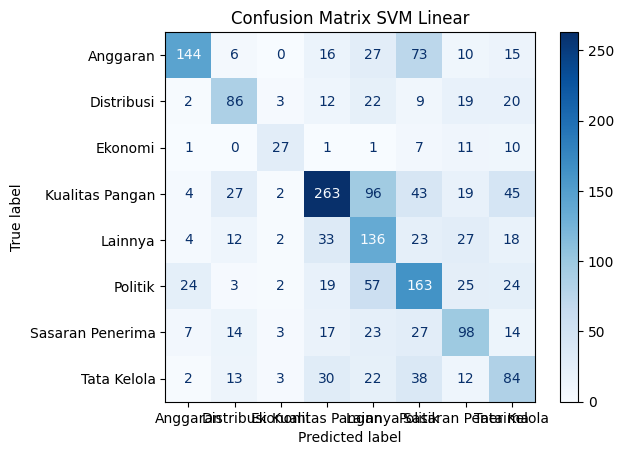

=== Weighted Average Metrics (Semua Kelas) ===
Accuracy : 50.05%
Precision (weighted): 53.90%
Recall    (weighted): 50.05%
F1-Score  (weighted): 50.96%


In [80]:
# Train model final SVM Linear dengan data resampled
model_linear = SVC(
    kernel='linear',
    C=0.1,
    probability=True,
    random_state=42
)
model_linear.fit(X_train_resampled, y_train_resampled)

# Prediksi dan evaluasi
y_pred = model_linear.predict(X_test_tfidf)

print("=== Classification Report SVM Linear ===")
print(classification_report(y_test, y_pred))
print("\n")

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model_linear.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix SVM Linear")
plt.show()

# print("=== Metrics untuk kelas 'Pro' SVM Linear ===")
# print(f"Accuracy : {accuracy_score(y_test, y_pred):.2%}")
# print(f"Precision: {precision_score(y_test, y_pred, average='weighted'):.2%}")
# print(f"Recall   : {recall_score(y_test, y_pred, average='weighted'):.2%}")
# print(f"F1-Score : {f1_score(y_test, y_pred, average='weighted'):.2%}")
# print("\n")

print("=== Weighted Average Metrics (Semua Kelas) ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.2%}")
print(f"Precision (weighted): {precision_score(y_test, y_pred, average='weighted'):.2%}")
print(f"Recall    (weighted): {recall_score(y_test, y_pred, average='weighted'):.2%}")
print(f"F1-Score  (weighted): {f1_score(y_test, y_pred, average='weighted'):.2%}")


In [81]:
param_grid = {
    'svc__gamma': ['scale','auto', 0.1, 1, 10, 100],
    'svc__C': [0.1, 1, 10]
}

pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),  # Menambahkan SMOTE untuk oversampling
    ('svc', SVC(kernel='rbf', random_state=42))  # Tanpa class_weight='balanced'
])

grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_tfidf, y_train)

print("Best params:", grid_search.best_params_)
y_pred = grid_search.predict(X_test_tfidf)
print("Accuracy:", accuracy_score(y_test, y_pred))

Best params: {'svc__C': 10, 'svc__gamma': 1}
Accuracy: 0.5505


=== Classification Report SVM RBF ===
                  precision    recall  f1-score   support

        Anggaran       0.69      0.66      0.67       291
      Distribusi       0.64      0.47      0.54       173
         Ekonomi       0.76      0.33      0.46        58
 Kualitas Pangan       0.55      0.74      0.63       499
         Lainnya       0.45      0.42      0.43       255
         Politik       0.47      0.51      0.49       317
Sasaran Penerima       0.60      0.44      0.51       203
     Tata Kelola       0.49      0.39      0.43       204

        accuracy                           0.55      2000
       macro avg       0.58      0.50      0.52      2000
    weighted avg       0.56      0.55      0.54      2000





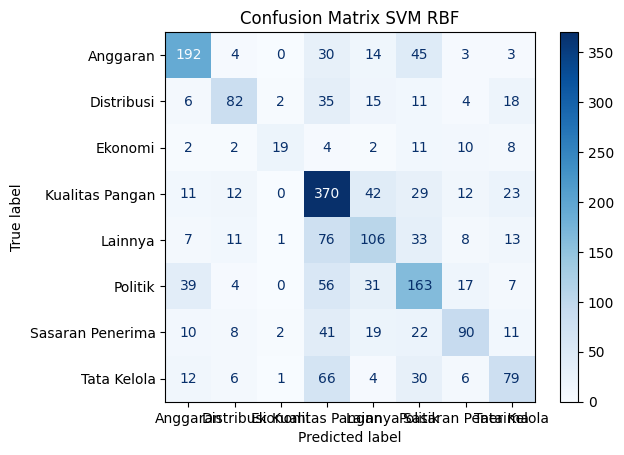

=== Weighted Average Metrics (Semua Kelas) ===
Accuracy : 55.05%
Precision (weighted): 55.71%
Recall    (weighted): 55.05%
F1-Score  (weighted): 54.45%


In [89]:
# Train model final SVM RBF dengan data resampled
model_rbf = SVC(
    kernel='rbf',
    C=10,
    gamma=1,
    probability=True,
    random_state=42
)
model_rbf.fit(X_train_resampled, y_train_resampled)

# Prediksi dan evaluasi
y_pred = model_rbf.predict(X_test_tfidf)

print("=== Classification Report SVM RBF ===")
print(classification_report(y_test, y_pred))
print("\n")

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model_rbf.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix SVM RBF")
plt.show()

# print("=== Metrics untuk kelas 'Pro' SVM RBF ===")
# print(f"Accuracy : {accuracy_score(y_test, y_pred):.2%}")
# print(f"Precision: {precision_score(y_test, y_pred, pos_label='Pro'):.2%}")
# print(f"Recall   : {recall_score(y_test, y_pred, pos_label='Pro'):.2%}")
# print(f"F1-Score : {f1_score(y_test, y_pred, pos_label='Pro'):.2%}")
# print("\n")

print("=== Weighted Average Metrics (Semua Kelas) ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.2%}")
print(f"Precision (weighted): {precision_score(y_test, y_pred, average='weighted'):.2%}")
print(f"Recall    (weighted): {recall_score(y_test, y_pred, average='weighted'):.2%}")
print(f"F1-Score  (weighted): {f1_score(y_test, y_pred, average='weighted'):.2%}")


In [78]:
print(train['label'].unique())

['Sasaran Penerima' 'Politik' 'Kualitas Pangan' 'Distribusi' 'Anggaran'
 'Ekonomi' 'Lainnya' 'Tata Kelola']


In [ ]:
import sys

# !{sys.executable} -m pip install scikit-learn
# !{sys.executable} -m pip install PySastrawi
# !{sys.executable} -m pip install openpyxl
# !{sys.executable} -m pip install nltk Sastrawi
# !{sys.executable} -m pip install scipy
!{sys.executable} -m pip install matplotlib
# !{sys.executable} -m pip install scikit-learn imbalanced-learn nltk Sastrawi openpyxl scipy
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.svm import SVC
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

In [ ]:
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory, ArrayDictionary, StopWordRemover
print("Import berhasil!")

Import berhasil!


In [ ]:


train_hasil = pd.DataFrame({
    
    'Prediksi': y_pred
})

train_hasil.to_excel('hasil_svm.xlsx', index=False)

In [102]:
test = pd.read_excel("excel/case_1_text_to_predict.xlsx")

# test['clean_text'] = test['full_text'].apply(clean_text)
test.head()

,id,full_text
0,TXT0001,@yeahhhmaybe mbg di sekolah kota saya belum ad...
1,TXT0002,@thefineshytguy WKWKKdidaerah ku pun yg dapat ...
2,TXT0003,"@ARSIPAJA Tai tau enggak ,gak semua sekolah da..."
3,TXT0004,"Gencar Cegah Stunting, MBG Telah Capai 49% Sas..."
4,TXT0005,140 siswa kupang Keracunan program MBG @prabowo


In [111]:
teks_baru = test['full_text']

In [112]:
X_new = vectorizer.transform(teks_baru)


In [116]:
prediksi = model_linear.predict(X_new)

KeyboardInterrupt: 

In [117]:
prediksi

array(['Distribusi', 'Distribusi', 'Kualitas Pangan', ..., 'Tata Kelola',
       'Lainnya', 'Lainnya'], shape=(1500,), dtype=object)

In [121]:
teks_baru = pd.DataFrame({
    
    'Prediksi': prediksi
})
 
teks_baru.to_excel('hasil_prediksi.xlsx', index=False)

NameError: name 'model' is not defined